# Handwritten Digit Classification with PyTorch

In this project, we build a Multi-Layer Perceptron (MLP) using PyTorch to classify handwritten digits from the MNIST dataset.

Dataset:
- 60,000 training images
- 10,000 test images
- 10 classes (0-9)

Goal:
Predict the digit shown in a 28x28 grayscale image.

--------------------------------------------------



<img src="https://skillicons.dev/icons?i=python,pytorch,git" />

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [3]:
train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

In [4]:
print(len(train_dataset))
print(len(test_dataset))

60000
10000


In [5]:
image, label = train_dataset[0]

print(image.shape)
print(label)

torch.Size([1, 28, 28])
5


### 1 = channel | 28 = height | 28 = width | label = 5

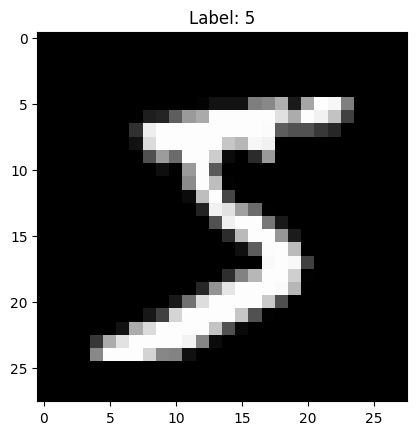

In [6]:
plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title(f"Label: {label}")
plt.show()

In [7]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [8]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


### 64 = batch size | 1 = channel | 28 = height | 28 = width

In [9]:
image = images[0]
print("Image Shape Before Flatten: ", image.shape)

print("----------------------------------------------------")

flattened = image.view(-1)
print('Flatten image Shape: ', flattened.shape)

Image Shape Before Flatten:  torch.Size([1, 28, 28])
----------------------------------------------------
Flatten image Shape:  torch.Size([784])


In [10]:
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):

        x = x.view(x.size(0), -1)
        
        return self.layers(x)

In [11]:
model = MLP()
sample_output = model(images)

print(sample_output.shape)

torch.Size([64, 10])


In [12]:
model = MLP().to(device)

In [13]:
criterion = nn.CrossEntropyLoss()

In [14]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [15]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([64, 10])


In [16]:
loss = criterion(
    outputs,
    labels
)

print(loss.item())

2.3079283237457275


In [17]:
num_epochs = 15

train_losses = []
test_losses = []

train_accuracies = []
test_accuracies = []

for epoch in range(num_epochs):

    # ====================
    # TRAIN
    # ====================

    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, dim=1)

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

    epoch_train_loss = (
        train_loss / len(train_loader)
    )

    epoch_train_acc = (
        100 * train_correct / train_total
    )

    train_losses.append(epoch_train_loss)

    train_accuracies.append(
        epoch_train_acc
    )

    # ====================
    # TEST
    # ====================

    model.eval()

    test_loss = 0
    test_correct = 0
    test_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            test_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                dim=1
            )

            test_total += labels.size(0)

            test_correct += (
                predicted == labels
            ).sum().item()

    epoch_test_loss = (
        test_loss / len(test_loader)
    )

    epoch_test_acc = (
        100 * test_correct / test_total
    )

    test_losses.append(
        epoch_test_loss
    )

    test_accuracies.append(
        epoch_test_acc
    )


    if epoch % 5 == 0:
        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Train Acc: {epoch_train_acc:.2f}% | "
            f"Test Loss: {epoch_test_loss:.4f} | "
            f"Test Acc: {epoch_test_acc:.2f}%"
        )

Epoch [1/15] Train Loss: 0.3478 | Train Acc: 90.14% | Test Loss: 0.1797 | Test Acc: 94.47%
Epoch [6/15] Train Loss: 0.0457 | Train Acc: 98.60% | Test Loss: 0.0848 | Test Acc: 97.42%
Epoch [11/15] Train Loss: 0.0181 | Train Acc: 99.43% | Test Loss: 0.0860 | Test Acc: 97.64%


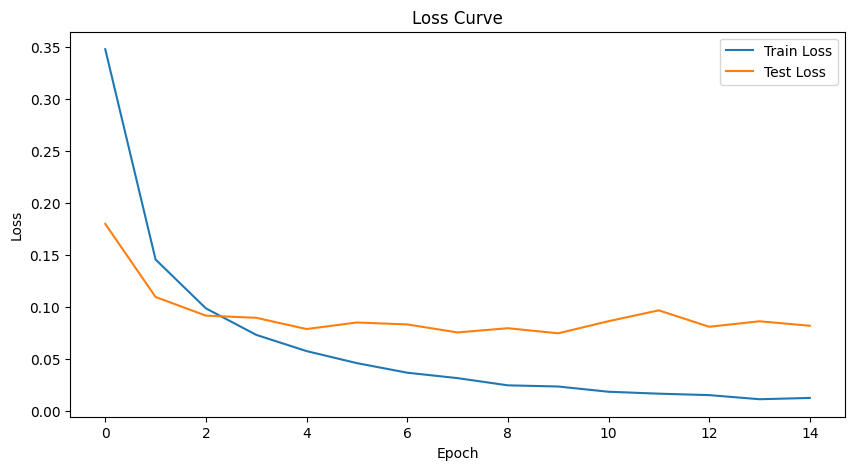

In [19]:
plt.figure(figsize=(10,5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    test_losses,
    label="Test Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Curve")

plt.legend()

plt.show()

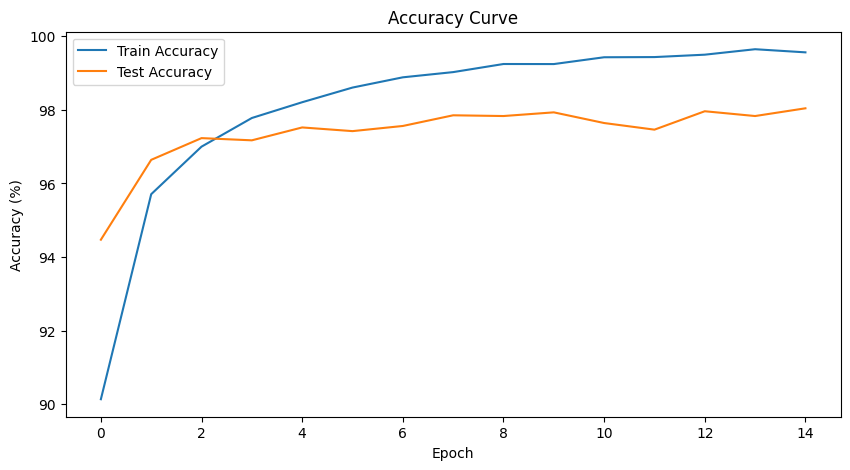

In [21]:
plt.figure(figsize=(10,5))

plt.plot(
    train_accuracies,
    label="Train Accuracy"
)

plt.plot(
    test_accuracies,
    label="Test Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title("Accuracy Curve")

plt.legend()

plt.show()

In [22]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, dim=1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

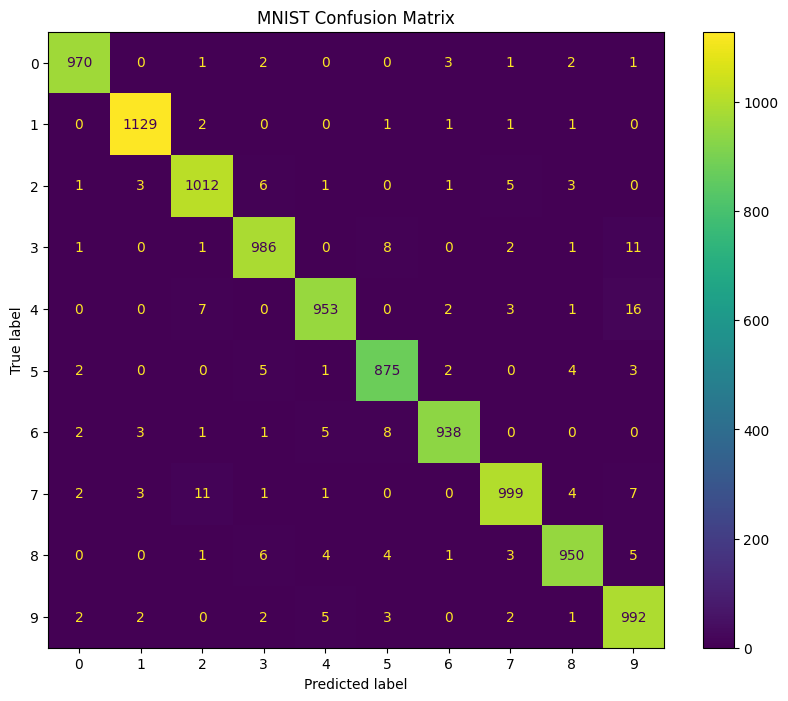

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

fig, ax = plt.subplots(figsize=(10, 8))

disp.plot(ax=ax)

plt.title("MNIST Confusion Matrix")

plt.show()

## 📊 Confusion Matrix Analysis

The confusion matrix shows that the model performs very well on the MNIST test set. Most predictions are concentrated along the main diagonal, which indicates that the majority of samples were classified correctly.

### Overall Performance

The strongest observation is the dominance of the diagonal values. For almost every digit, the number of correct predictions is significantly higher than the number of misclassifications. This suggests that the MLP successfully learned the underlying patterns of handwritten digits despite its relatively simple architecture.

---

### Digits with Strong Performance

The model achieved particularly high recognition rates for:

- **Digit 1** (`1129` correct predictions)
- **Digit 7** (`999` correct predictions)
- **Digit 9** (`992` correct predictions)
- **Digit 3** (`986` correct predictions)
- **Digit 0** (`970` correct predictions)

These digits appear to have more distinctive visual characteristics, making them easier for the network to separate from other classes.

---

### Common Misclassifications

Although the overall performance is strong, a few recurring mistakes can be observed:

| True Digit | Predicted As | Count |
|------------|-------------|--------|
| 4 | 9 | 16 |
| 7 | 2 | 11 |
| 3 | 9 | 11 |
| 6 | 5 | 8 |
| 3 | 5 | 8 |

These errors are understandable because some handwritten digits can look very similar depending on writing style. For example:

- A poorly written **4** may resemble a **9**.
- Certain forms of **7** can be confused with **2**.
- Rounded **3** shapes sometimes resemble **5** or **9**.

---

### Class-wise Observations

#### Digit 0
The model classified digit **0** almost perfectly, with only a handful of errors distributed across other classes.

#### Digit 1
Digit **1** achieved the best results overall and was rarely confused with any other digit.

#### Digit 4
The largest source of error for this class was confusion with digit **9**, indicating that the model struggles with certain handwritten styles where these two digits share similar shapes.

#### Digit 5 and 6
A noticeable amount of confusion exists between **5** and **6**, which is expected due to their similar curved structures in handwritten form.

---

### Conclusion

The confusion matrix demonstrates that the MLP has learned the MNIST dataset effectively and generalizes well to unseen test samples. Most errors occur between visually similar digits rather than completely unrelated classes, which is a positive sign that the model has captured meaningful visual features.

Considering that this project uses a simple fully-connected neural network rather than a convolutional architecture, the achieved performance is highly satisfactory. Future improvements could include:

- Adding more hidden layers
- Introducing Dropout regularization
- Using Batch Normalization
- Replacing the MLP with a Convolutional Neural Network (CNN)

These modifications would likely reduce the remaining classification errors and improve overall accuracy.